## IRL4RA --- Experiments II

In this notebook, we validate our particle-based algorithm for various risk preferences. We consider risk measures of the form
$$
\rho_{\mu}(X) = \int_{0}^{1} \text{AV@R}_{1-\alpha}(X) \mu( \textrm{d} \alpha),
$$
where $\mu \in \mathcal{P}_{\lambda}([0,1])$, allowing more flexibility than the previous set of experiments.

We note that the algorithm provided in this notebook may be easily modified according to the application of interest.

In [ ]:
# load python libraries
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import time
from google.colab import files

### Definition of functions

We group all functions of the particle-based algorithm within its own class. The `train` function corresponds to the full algorithm depicted in the paper which calls three main components: (i) `update_particle` to update both the cost $c_\ell$ and risk-aversion $\mu_\ell$ of each particle $\ell = 1,\ldots,K_\ell$; (ii) `eliminate_particle` to remove particles from the system; and (iii) `replenish_particle` to add new particles once in a while.

In [ ]:
class PSOalgo():
    """ constructor of the learning algorithm
    """
    def __init__(self, n_dC, n_particle, n_dkappa):

        # hyperparameters
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.n_dC = n_dC
        self.n_particle = n_particle
        self.n_dkappa = n_dkappa

    def select_optimal_action(self, C0, sigma0, p_mat, q_mat):
        """selects optimal action according to the client's risk preferences
        """
        p_, q_ = self.mat_to_p(p_mat), self.mat_to_p(q_mat)
        p_mat_0, q_mat_0 = self.p_to_mat(p_, n_dkappa=sigma0.shape[-1]), self.p_to_mat(q_, n_dkappa=sigma0.shape[-1])
        if self.eval_rho(p_mat_0, C0, sigma0)[0] < self.eval_rho(q_mat_0, C0, sigma0)[0]:
            action = 1
        else:
            action = -1
        return action

    def move_particle(self, drift_C=1, noise_C=0, drift_kappa=1, noise_kappa=0):
        """description
        """
        # calculate penalizations
        sigma_ = self.map_kappa_to_sigma(self.kappa)
        rho_p_hist = self.eval_rho_hist(self.p_mat_hist[:self.n_round], self.C, sigma_)
        rho_q_hist = self.eval_rho_hist(self.q_mat_hist[:self.n_round], self.C, sigma_)
        pen = F.relu( (rho_p_hist - rho_q_hist) / ((rho_p_hist + rho_q_hist).detach()) * self.a_mat_hist[:self.n_round].unsqueeze(-1))
        freq_out = (torch.sum(pen > 0, -1) / sigma_.shape[0]).detach().cpu().numpy()
        pen = pen.sum()
        tail_len = max(1, self.kappa.shape[-1] // 10)
        pen = pen + 0.01 * (self.kappa[..., -tail_len:]**2).mean() / self.kappa.sum().detach()

        # gradient descent
        self.C.grad, self.kappa.grad = None, None
        pen.backward()
        with torch.no_grad():
            self.C[:,1] = F.relu(self.C[:,1] - drift_C * self.C.grad[:,1] + noise_C * (torch.rand(size=self.C[:,1].shape, device=self.device)-0.5) )
            self.C[:,1] = self.C[:,1] - F.relu(self.C[:,1]-1)
            dkappa = - drift_kappa * self.kappa.grad + noise_kappa * torch.rand(size=self.kappa.shape, device=self.device)
            dkappa = dkappa - (dkappa*self.rescale_kappa).mean(-1).unsqueeze(-1)*self.rescale_kappa**(-1)/self.kappa.shape[-1]
            self.kappa = F.relu(self.kappa + dkappa)
            self.kappa = self.scale_kappa(self.kappa, rescale_factors=self.rescale_kappa)
            self.sigma = self.map_kappa_to_sigma(self.kappa)

        return freq_out

    def eliminate_particle(self):
        """description
        """
        with torch.no_grad():
            rho_p_hist = self.eval_rho_hist(self.p_mat_hist[:self.n_round], self.C, self.sigma)
            rho_q_hist = self.eval_rho_hist(self.q_mat_hist[:self.n_round], self.C, self.sigma)
            pen = F.relu( (rho_p_hist - rho_q_hist) / (rho_p_hist + rho_q_hist) * self.a_mat_hist[:self.n_round].unsqueeze(-1) ).sum(0)
            n_out = torch.sum(pen > 0)
            idx = pen.sort()[-1]
            n_remained = int((self.C.shape[0]-n_out).detach().cpu().numpy())
            self.C = torch.clone(self.C[idx][0:n_remained])
            self.kappa = torch.clone(self.kappa[idx][0:n_remained])
            self.sigma = self.map_kappa_to_sigma(self.kappa)
            return n_remained

    def replenish_particle(self, noise_scale_C=1, noise_scale_kappa=0.0, ratio_explore=0.025):
        """description
        """
        n_left = self.C.shape[0]
        n_new = self.n_particle - n_left
        if n_left < self.n_particle:
            idx = np.random.choice(n_left, n_new)
            C_new, kappa_new = self.C[idx], self.kappa[idx]
            C_new[:,1] = F.relu( C_new[:,1] + noise_scale_C * self.C[:,1].std() * (torch.rand(n_new, device=self.device)-0.5) )
            C_new[:,1] = C_new[:,1] - F.relu(C_new[:,1] - 1)
            kappa_new = F.relu( kappa_new + noise_scale_kappa * self.kappa.std(0).unsqueeze(0) * torch.rand(kappa_new.shape, device=self.device) )
            kappa_new = self.scale_kappa(kappa_new, rescale_factors=self.rescale_kappa).detach()
            self.C = torch.cat((self.C,C_new), dim=0)
            self.kappa = torch.cat((self.kappa,kappa_new), dim=0)
            self.sigma = self.map_kappa_to_sigma(self.kappa)
            if ratio_explore > 0:
                n_explore = max(int(ratio_explore*self.n_particle), 1)
                self.C[-n_explore:, 1] = torch.rand(size=(n_explore,), device=self.device)

    def initialize_particle(self):
        # costs for all particles
        self.C = torch.rand(size=(self.n_particle, self.n_dC), device=self.device).sort()[0]
        self.C[:, 0] = 0
        self.C[:,-1] = 1

        # kappa/sigma for all particles
        self.rescale_kappa = torch.arange(self.n_dkappa,0,-1, device=self.device).unsqueeze(0) / self.n_dkappa
        self.kappa = torch.rand(size=[self.n_particle,self.n_dkappa], device=self.device)
        for j in range(self.n_particle):
            temp = torch.distributions.Dirichlet(torch.ones(self.n_dkappa)).sample((1,)).to(self.device)[0]
            self.kappa[j] = torch.distributions.Dirichlet(temp).sample((1,))[0]

        self.kappa = self.scale_kappa(self.kappa, rescale_factors=self.rescale_kappa)
        self.sigma = self.map_kappa_to_sigma(self.kappa)

    def train(self, C0, sigma0, n_interac, n_update):
        """main training loop for the particle optimization algorithm
        """
        # objects for training history
        self.p_mat_hist = torch.zeros(size=(n_interac, 3, self.n_dkappa), device=self.device)
        self.q_mat_hist = torch.zeros(size=(n_interac, 3, self.n_dkappa), device=self.device)
        self.a_mat_hist = torch.zeros(size=(n_interac,), device=self.device)
        self.Psi_hist = torch.zeros(size=(n_interac,), device=self.device)
        self.c_est_hist = torch.zeros(size=(n_interac,), device=self.device)
        self.sigma_est_hist = torch.zeros(size=(n_interac, self.n_dkappa), device=self.device)
        self.Psi_lst_hist = []
        self.n_round = 0
        self.total_time = 0

        # initialize particles
        self.initialize_particle()
        self.activate_grad()

        for _ in range(n_interac):

            start_time = time.time()

            # design environments
            Psi_design, p_mat_design, q_mat_design, Psi_lst = self.design_pq(dp=0.01)
            if Psi_design > 0:
                self.n_round = self.n_round + 1
                self.Psi_lst_hist.append(Psi_lst)
                self.Psi_hist[self.n_round-1] = Psi_design
                self.p_mat_hist[self.n_round-1], self.q_mat_hist[self.n_round-1] = p_mat_design.clone(), q_mat_design.clone()
            else:
                print('Terminated early as no distinguishing environment.')
                break

            # determine which action is optimal
            self.a_mat_hist[self.n_round-1] = self.select_optimal_action(
                C0, sigma0, p_mat=self.p_mat_hist[self.n_round-1], q_mat=self.q_mat_hist[self.n_round-1])

            # update particles
            for ii in range(n_update):
                freq_out = self.move_particle(
                    drift_C=0, noise_C=0, noise_kappa=0,
                    drift_kappa=self.rescale_kappa*self.kappa.std(0).mean()/self.n_round**.5/self.n_dkappa)
                self.activate_grad()

                # stop loop if number of particles is small enough
                if np.sort(np.array(freq_out))[::-1][:5].sum() < 0.02:
                    print('First move terminated early with', ii, 'updates and', np.sort(np.array(freq_out))[::-1][:5].sum())
                    break

            # eliminate particles
            n_remained = self.eliminate_particle()
            print('First ELM:', n_remained, 'particles remained.')

            with torch.no_grad():
                self.c_est_hist[self.n_round-1] = torch.clone(self.C[:,1]).mean()
                self.sigma_est_hist[self.n_round-1] = torch.clone(self.sigma.mean(0))
                print('c_est:', self.C[:,1].mean(), self.C[:,1].std())

            # stop training if there is not enough particles
            if n_remained < 0.05*self.n_particle:
                print('Break at', self.n_round)
                break

            # create additional particles
            self.replenish_particle(noise_scale_C=0, noise_scale_kappa=0, ratio_explore=0)
            self.activate_grad()

            # update particles
            _ = self.move_particle(
                drift_C=2*torch.clip(self.C[:,1].std(),max=0.05), noise_C=torch.clip(self.C[:,1].std(),max=0.05), drift_kappa=0, noise_kappa=0)
            self.activate_grad()

            # update particles
            for ii in range(5*n_update):
                freq_out = self.move_particle(
                    drift_C= 0, noise_C=0, noise_kappa=0,
                    drift_kappa=self.rescale_kappa*self.kappa.std(0).mean()/self.n_round**.5/self.n_dkappa)
                self.activate_grad()

                # stop loop if number of particles is small enough
                if np.sort(np.array(freq_out))[::-1][:5].sum() < 0.1:
                    print('Second Move Terminated early with', ii, 'updates and', np.sort(np.array(freq_out))[::-1][:5].sum())
                    break

            # eliminate particles
            n_remained = self.eliminate_particle()
            self.activate_grad()
            print('Second ELM:', n_remained, 'particles remained.')

            with torch.no_grad():
                self.c_est_hist[self.n_round-1] = torch.clone(self.C[:,1]).mean()
                self.sigma_est_hist[self.n_round-1] = torch.clone(self.sigma.mean(0))
                print('c_est:', self.C[:,1].mean(), self.C[:,1].std())

            # stop training if there is not enough particles
            if n_remained < 0.05*self.n_particle:
                print('Break at', self.n_round)
                break

            end_time = time.time()
            self.total_time = self.total_time + end_time - start_time
            print('Round', self.n_round, 'takes', end_time-start_time, 'seconds.')

        print('** This block takes', self.total_time, 'seconds. **')
        print('number of effective particles:', n_remained)
        print('number of interactions:', self.n_round)
        print('True c:', C0[0,1], '      particle mean:', self.c_est_hist[self.n_round-1])

    def design_pq(self, dp=0.01):
        """designs the environment
        """
        n_dp = int(np.floor(1/dp))
        p_vec = np.arange(1,n_dp) * dp
        q_vec = np.arange(1,n_dp) * dp
        Psi_ret = 0
        Psi_lst = []
        p_temp, q_temp = np.random.rand(), np.random.rand()
        p_mat_ret = self.p_to_mat(torch.tensor([1-p_temp,p_temp,0], device=self.device), self.n_dkappa)
        q_mat_ret = self.p_to_mat(torch.tensor([1-q_temp, 0, q_temp], device=self.device), self.n_dkappa)

        n_particle_ = self.kappa.shape[0]
        idx1 = np.random.choice(n_particle_, n_particle_, replace=False)
        idx2 = np.copy(idx1[::-1])
        C1, sigma1 = self.C[idx1], self.sigma[idx1]
        C2, sigma2 = self.C[idx2], self.sigma[idx2]
        with torch.no_grad():
            for i in range(n_dp-1):
                # compute risk for G under action A
                p_mat_temp = self.p_to_mat(torch.tensor([1-p_vec[i],p_vec[i],0], device=self.device), self.n_dkappa)
                rho_p_1, rho_p_2 = self.eval_rho(p_mat_temp, C1, sigma1), self.eval_rho(p_mat_temp, C2, sigma2)
                for j in range(i):
                    # compute risk for G under action B
                    q_mat_temp = self.p_to_mat(torch.tensor([1-q_vec[j],0,q_vec[j]], device=self.device), self.n_dkappa)
                    rho_q_1, rho_q_2 = self.eval_rho(q_mat_temp, C1, sigma1), self.eval_rho(q_mat_temp, C2, sigma2)
                    # calculate relative distinguishing power
                    Psi_temp = torch.sqrt( F.relu( (rho_p_1-rho_q_1) * (rho_q_2-rho_p_2) / (rho_p_1+rho_q_1) / (rho_p_2+rho_q_2) ) ).mean()
                    Psi_lst.append(Psi_temp.detach().cpu().numpy())
                    if Psi_temp > Psi_ret:
                        Psi_ret, p_mat_ret, q_mat_ret = Psi_temp, p_mat_temp, q_mat_temp

        return Psi_ret, p_mat_ret, q_mat_ret, Psi_lst

    def p_to_mat(self, p_, n_dkappa, epsilon=1e-4):
        """transforms p_ (tensor of length n_dC) to a matrix, shape = (n_dC, n_dkappa)
        """
        F_ = torch.cumsum(p_.float(), -1) * n_dkappa
        F_[-1] = n_dkappa
        n_row = p_.shape[0]
        ret = torch.zeros([n_row, n_dkappa], device=self.device)

        F_floor = torch.floor(F_ + epsilon)

        F_prev = torch.cat([torch.zeros(1, device=self.device), F_[:-1]])
        F_prev_floor = torch.floor(F_prev + epsilon)

        cols = torch.arange(n_dkappa, device=self.device).expand(n_row, -1)

        full_mask = (cols > F_prev_floor.unsqueeze(1)) & (cols < F_floor.unsqueeze(1))
        left_mask = cols == F_prev_floor.unsqueeze(1)
        left_vals = torch.ceil(F_prev + epsilon) - F_prev
        right_mask = cols == F_floor.unsqueeze(1)
        right_vals = (F_ - torch.floor(F_)).clamp(min=0.0)

        ret[full_mask] = 1.0
        ret[left_mask] = left_vals[left_mask.any(dim=1)]
        ret[right_mask] = right_vals[right_mask.any(dim=1)]
        ret[p_ == 0] = 0.0

        return ret

    def mat_to_p(self, p_mat):
        """transforms mat (matrix of size (n_dC, n_dkappa)) to p_, shape = (n_dC)
        """
        p_ = p_mat.sum(-1)
        return p_ / p_.sum()

    def eval_rho(self, p_mat_, C_, sigma):
        """evaluates the risk measure, shape = (1, n_particle)
        """
        ret = (p_mat_.unsqueeze(0) * C_.unsqueeze(-1)).sum(-2) * sigma
        return ret.sum(-1) / sigma.shape[-1]

    def eval_rho_hist(self, p_mat_hist, C_, sigma):
        """evaluates the risk measure, shape = (n_hist, n_particle)
        """
        ret = (p_mat_hist.unsqueeze(1) * C_.unsqueeze(-1).unsqueeze(0)).sum(-2) * sigma.unsqueeze(0)
        return ret.sum(-1) / sigma.shape[-1]

    def scale_kappa(self, kappa, rescale_factors=1.0):
        """returns a scaled version of kappa, shape = (n_particle, n_dkappa)
        """
        kappa_mass = (kappa * rescale_factors).sum(-1).unsqueeze(-1)
        return kappa / kappa_mass

    def map_kappa_to_sigma(self, kappa):
        """maps kappa to sigma, shape = (n_particle, n_dkappa)
        """
        return torch.cumsum(kappa, -1)

    def activate_grad(self):
        """set requires_grad for the costs and kappa of all particles
        """
        self.C = nn.Parameter(self.C, requires_grad=True)
        self.kappa = nn.Parameter(self.kappa, requires_grad=True)

### Initialization of hyperparameters

We use the following notation:
- A finite set of $K_\ell$ particles
- $J$ points uniformly distributed on $[0,1]$ for $\mu_\ell$ with $\ell=1,\ldots,K_\ell$
- $4J$ points uniformly distributed on $[0,1]$ for $\mu_0$


In [ ]:
"""
EXPERT AND LEARNER PARAMETERS
"""
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # get device

n_dC = 3  # number of costs
C_x0, C_x1, C_x2 = 0.0, 0.3, 1.0  # values for the costs C(x0), C(x1), C(x2)

n_dkappa = 100  # number of points on [0,1] uniformly distributed for kappa
n_dkappa0 = 4 * n_dkappa  # number of points on [0,1] uniformly distributed for kappa0

n_particle = 1000  # number of particles for particle swarm optimization
n_interac = 50  # number of interactions
n_update = 1000  # number of updates per iteration

if True: ### option 1
    np.random.seed(123456)
    torch.manual_seed(123456)
    temp = torch.distributions.Dirichlet(torch.ones(n_dkappa0)).sample((1,)).to(device)[0]
    kappa0 = torch.distributions.Dirichlet(temp).sample((1,)).to(device)
elif False: ### option 2
    kappa0 = torch.arange(0,n_dkappa0, device=device)
elif False: ### option 3
    kappa0 = torch.arange(n_dkappa0,0,-1, device=device)

### Learning algorithm

In this setting, we verify that the learner can accurately infer the true cost and risk preferences of the client within a reasonable number of questions. We output some relevant statistics during the training session.

In [ ]:
algo = PSOalgo(n_dC, n_particle, n_dkappa)

# true risk preferences
C0 = torch.tensor((C_x0, C_x1, C_x2), device=device).unsqueeze(0)
rescale_kappa0 = torch.arange(n_dkappa0,0,-1, device=device).unsqueeze(0) / n_dkappa0
kappa0 = algo.scale_kappa(kappa0, rescale_factors=rescale_kappa0)
sigma0 = algo.map_kappa_to_sigma(kappa0)

algo.train(C0, sigma0, n_interac, n_update)

First ELM: 642 particles remained.
c_est: tensor(0.3795, device='cuda:0') tensor(0.1722, device='cuda:0')
Second Move Terminated early with 46 updates and 0.09900001
Second ELM: 903 particles remained.
c_est: tensor(0.3652, device='cuda:0') tensor(0.1692, device='cuda:0')
Round 1 takes 8.162592649459839 seconds.
First ELM: 424 particles remained.
c_est: tensor(0.2241, device='cuda:0') tensor(0.0850, device='cuda:0')
Second Move Terminated early with 7 updates and 0.09900001
Second ELM: 913 particles remained.
c_est: tensor(0.2146, device='cuda:0') tensor(0.0842, device='cuda:0')
Round 2 takes 8.15978455543518 seconds.
First ELM: 702 particles remained.
c_est: tensor(0.2514, device='cuda:0') tensor(0.0539, device='cuda:0')
Second Move Terminated early with 80 updates and 0.09900001
Second ELM: 907 particles remained.
c_est: tensor(0.2532, device='cuda:0') tensor(0.0506, device='cuda:0')
Round 3 takes 8.228516340255737 seconds.
First ELM: 887 particles remained.
c_est: tensor(0.2553, dev

This figure compares the true client's risk aversion $\mu_0$ and the estimation $\bar{\mu}$ from the algorithm.

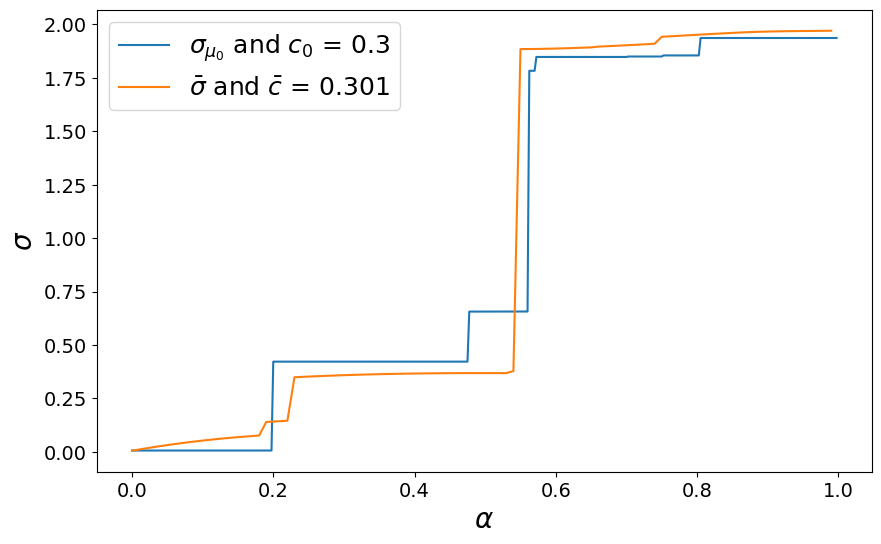

In [ ]:
fig, axes = plt.subplots(figsize=(10,6))

x0_plot = np.arange(n_dkappa0) / n_dkappa0
sigma0_plot = sigma0.cpu().numpy()[0,:]
axes.plot(x0_plot, sigma0_plot,
          label=r'$\sigma_{\mu_0}$ and $c_0$ = ' + str(np.round(C_x1,3)))

# for i in range(n_dkappa0):
#     x_temp = x0_plot[i]
#     s_temp = sigma0_plot[i]
#     axes.plot([x_temp, x_temp+1/n_dkappa0], [s_temp, s_temp],color='C0')

x_plot = np.arange(n_dkappa) / n_dkappa
sigma_plot = algo.sigma_est_hist[algo.n_round-1].detach().cpu().numpy()
axes.plot(x_plot, sigma_plot,
          label=r'$\bar{\sigma}$ and $\bar{c}$ = ' + str(np.round(algo.c_est_hist[algo.n_round-1].detach().cpu().numpy(),3)))

# for i in range(n_dkappa):
#     x_temp = x_plot[i]
#     s_temp = sigma_plot[i]
#     axes.plot([x_temp, x_temp+1/n_dkappa], [s_temp, s_temp], color='C1')

axes.set_xlabel(r'$\alpha$', fontsize=20)
axes.set_ylabel(r'$\sigma$', fontsize=20)
axes.tick_params(axis='both', labelsize=14)
axes.legend(fontsize=18)

# plt.savefig("sigma-estimation.pdf", transparent=False, bbox_inches='tight')
# files.download("sigma-estimation.pdf")
# plt.clf()
# plt.close()
plt.show()

This figure shows the different errors of the learner's estimation at each round. From top to bottom, we observe the absolute error on the cost function, the distance $\widetilde{\mathcal{U}}$ between $\mu_0$ and $\bar{\mu}$, and the distinguishing power respectively.

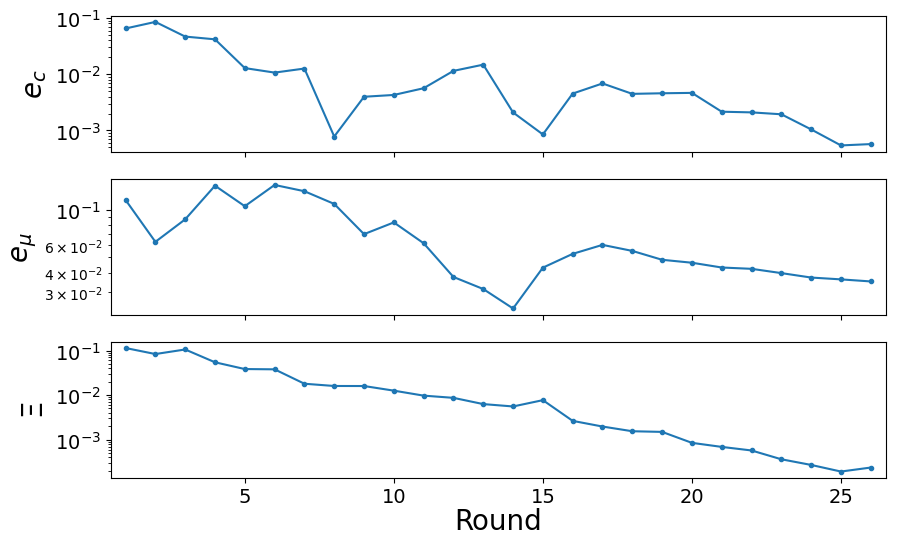

In [ ]:
def compute_Utilde(sigma, sigma0, n_dkappa0, skip_=4):
    diff_CDF = 0
    nu = 0
    for i in range(n_dkappa0):
        s_temp = sigma[i//skip_]
        diff_CDF = diff_CDF + (sigma0[0,i] - s_temp)
        if diff_CDF.abs() > nu:
            nu = diff_CDF.abs()
    return nu / n_dkappa0

c_err_plot = (algo.c_est_hist[:(algo.n_round-1)]-C0[0,1]).detach().cpu().numpy()
mu_err_plot = np.zeros(algo.n_round-1)
for i in range(algo.n_round-1):
    temp = compute_Utilde(algo.sigma_est_hist[i], sigma0, n_dkappa0)
    mu_err_plot[i] = temp.detach().cpu().numpy()
Psi_plot = algo.Psi_hist[:(algo.n_round-1)].detach().cpu().numpy()

fig, axes = plt.subplots(3, 1, figsize=(10,6), sharex='all')
grid = plt.GridSpec(3, 1)

axes[0].plot(np.arange(algo.n_round-1)+1, np.abs(c_err_plot),'.-')
axes[0].set_yscale('log')
axes[0].set_ylabel(r'$e_{c}$', fontsize=20)
axes[0].tick_params(axis='both', labelsize=14)
axes[1].plot(np.arange(algo.n_round-1)+1, mu_err_plot,'.-')
axes[1].set_yscale('log')
axes[1].set_ylabel(r'$e_{\mu}$', fontsize=20)
axes[1].tick_params(axis='both', labelsize=14)
axes[2].plot(np.arange(algo.n_round-1)+1, Psi_plot,'.-')
axes[2].set_yscale('log')
axes[2].set_ylabel(r'$\Xi$', fontsize=20)
axes[2].tick_params(axis='both', labelsize=14)
axes[2].set_xlim(0.5,algo.n_round-0.5)

xyaxis=fig.add_subplot(grid[:,:], frameon=False)
xyaxis.set_xlabel('Round', fontsize=20)
xyaxis.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)

# plt.savefig("errors-convergence.pdf", transparent=False, bbox_inches='tight')
# files.download("errors-convergence.pdf")
# plt.clf()
# plt.close()
plt.show()

Finally, this figure shows exactly which matrix $G_{p,q}$ is chosen at each round to differentiate between risk aversions and, as expected, the questions are located near the indifference line.

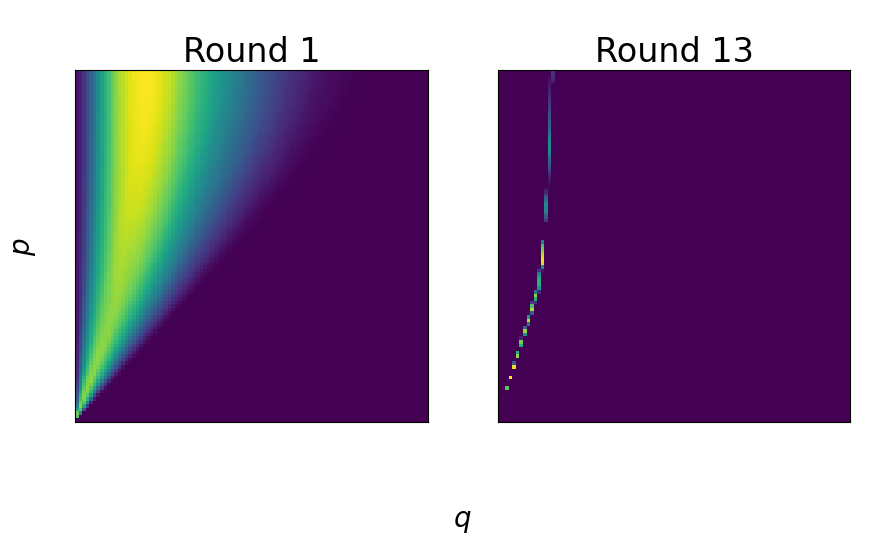

In [ ]:
n_dp = 100
def Psi_lst_to_mat(Psi_lst, n_dp):
    idx = 0
    Psi_mat = np.zeros((n_dp-1,n_dp-1))
    for i in range(n_dp-1):
        for j in range(i):
            Psi_mat[i,j] = Psi_lst[idx]
            idx = idx + 1
    return Psi_mat[::-1]

fig, axes = plt.subplots(1, 2, figsize=(10,6), sharex='all', sharey='all')

axes[0].imshow(Psi_lst_to_mat(algo.Psi_lst_hist[0], n_dp))
axes[0].set_title('Round '+str(1), fontsize=24)
axes[0].set_xticks([], [])
axes[0].set_yticks([], [])
axes[1].imshow(Psi_lst_to_mat(algo.Psi_lst_hist[algo.n_round//2], n_dp))
axes[1].set_title('Round '+str((algo.n_round-2)//2+1), fontsize=24)
axes[1].set_xticks([], [])
axes[1].set_yticks([], [])

xyaxis=fig.add_subplot(grid[:,:], frameon=False)
xyaxis.set_xlabel(r'$q$', fontsize=20)
xyaxis.set_ylabel(r'$p$', fontsize=20)
xyaxis.tick_params(labelcolor='none', which='both', top=False, bottom=False, left=False, right=False)

# plt.savefig("game-power.pdf", transparent=False, bbox_inches='tight')
# files.download("game-power.pdf")
# plt.clf()
# plt.close()
plt.show()

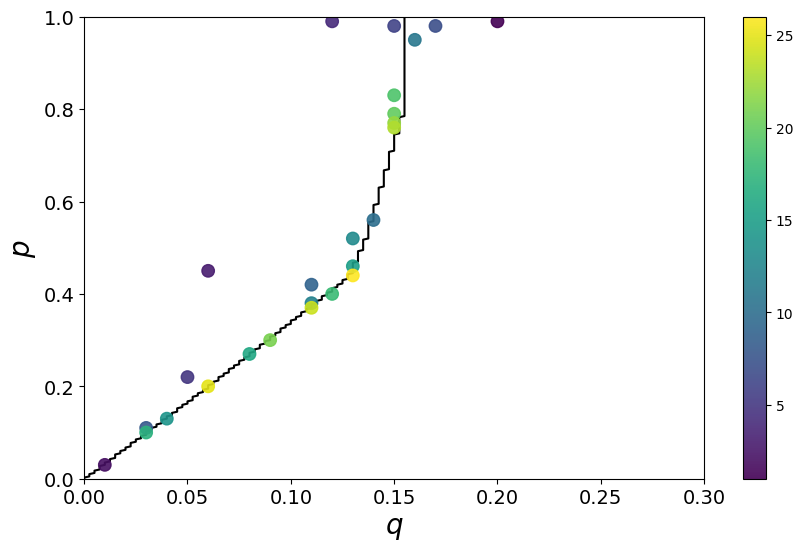

In [ ]:
fig, axes = plt.subplots(figsize=(10,6))

x_grid = np.arange(n_dkappa0) / n_dkappa0
s0 = sigma0.squeeze().detach().cpu().numpy()
areas = (s0[:-1] + s0[1:]) * 0.5 * np.diff(x_grid)
int_qs = 1 - np.concatenate(([0.0], np.cumsum(areas)))
indiff_line = x_grid[len(x_grid) - np.searchsorted(-int_qs, -C_x1*int_qs, side='left')][::-1]

p_plot = (algo.p_mat_hist.sum(-1) / n_dp)[:algo.n_round-1,1].detach().cpu().numpy()
q_plot = (algo.q_mat_hist.sum(-1) / n_dp)[:algo.n_round-1,2].detach().cpu().numpy()

axes.plot(indiff_line, x_grid, color='k')
temp = axes.scatter(q_plot, p_plot, s=80, c=range(1,len(q_plot)+1), alpha=0.90, zorder=2)
plt.colorbar(temp)

axes.set_xlabel(r"$q$", fontsize=20)
axes.set_ylabel(r"$p$", fontsize=20)
axes.set_xlim(0.0, 0.3)
axes.set_ylim(0.0, 1.0)
axes.tick_params(axis='both', labelsize=14)

# plt.savefig("game-selection.pdf", transparent=False, bbox_inches='tight')
# files.download("game-selection.pdf")
# plt.clf()
# plt.close()
plt.show()